In [39]:
import os
import pathlib
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [40]:
UNRAVELED_DATA_DIR = pathlib.Path('../datasets/cherry-picked/unraveled/processed_unraveled.csv')

In [41]:
unraveled_flows = pd.read_csv(UNRAVELED_DATA_DIR)

/tmp/ipykernel_2876/1940393123.py:1: DtypeWarning: Columns (0: requested_server_name, 1: client_fingerprint, 2: server_fingerprint, 3: user_agent, 4: content_type, 5: Signature) have mixed types. Specify dtype option on import or set low_memory=False.
  unraveled_flows = pd.read_csv(UNRAVELED_DATA_DIR)


In [42]:
unraveled_flows.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,6265795.0,49949.506164,4.850447e+04,0.000000e+00,12953.0,33860.0,72276.0,2.451180e+05
expiration_id,6265795.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00
src_port,6265795.0,44784.241342,1.544377e+04,0.000000e+00,39040.0,48253.0,55299.0,6.553500e+04
dst_port,6265795.0,410.388308,7.761627e+02,0.000000e+00,53.0,123.0,443.0,1.423800e+04
protocol,6265795.0,12.527141,5.427047e+00,1.000000e+00,6.0,17.0,17.0,1.700000e+01
...,...,...,...,...,...,...,...,...
dst2src_fin_packets,6265795.0,0.375537,4.886243e-01,0.000000e+00,0.0,0.0,1.0,2.000000e+00
application_is_guessed,6265795.0,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00
delta_t_bidirectional,6265795.0,218.369613,9.419361e+06,-3.501528e+09,3.0,40.0,1761.0,2.446107e+09
delta_t_src2dst,6265795.0,218.369613,9.419361e+06,-3.501528e+09,3.0,40.0,1761.0,2.446107e+09


In [43]:
unraveled_flows.columns

Index(['id', 'expiration_id', 'src_ip', 'src_mac', 'src_oui', 'src_port',
       'dst_ip', 'dst_mac', 'dst_oui', 'dst_port', 'protocol', 'ip_version',
       'vlan_id', 'tunnel_id', 'bidirectional_duration_ms',
       'bidirectional_packets', 'bidirectional_bytes', 'src2dst_duration_ms',
       'src2dst_packets', 'src2dst_bytes', 'dst2src_duration_ms',
       'dst2src_packets', 'dst2src_bytes', 'bidirectional_min_ps',
       'bidirectional_mean_ps', 'bidirectional_stddev_ps',
       'bidirectional_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps',
       'src2dst_stddev_ps', 'src2dst_max_ps', 'dst2src_min_ps',
       'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps',
       'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms',
       'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms',
       'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms',
       'src2dst_max_piat_ms', 'dst2src_min_piat_ms', 'dst2src_mean_piat_ms',
       'dst2src_stddev_piat_ms'

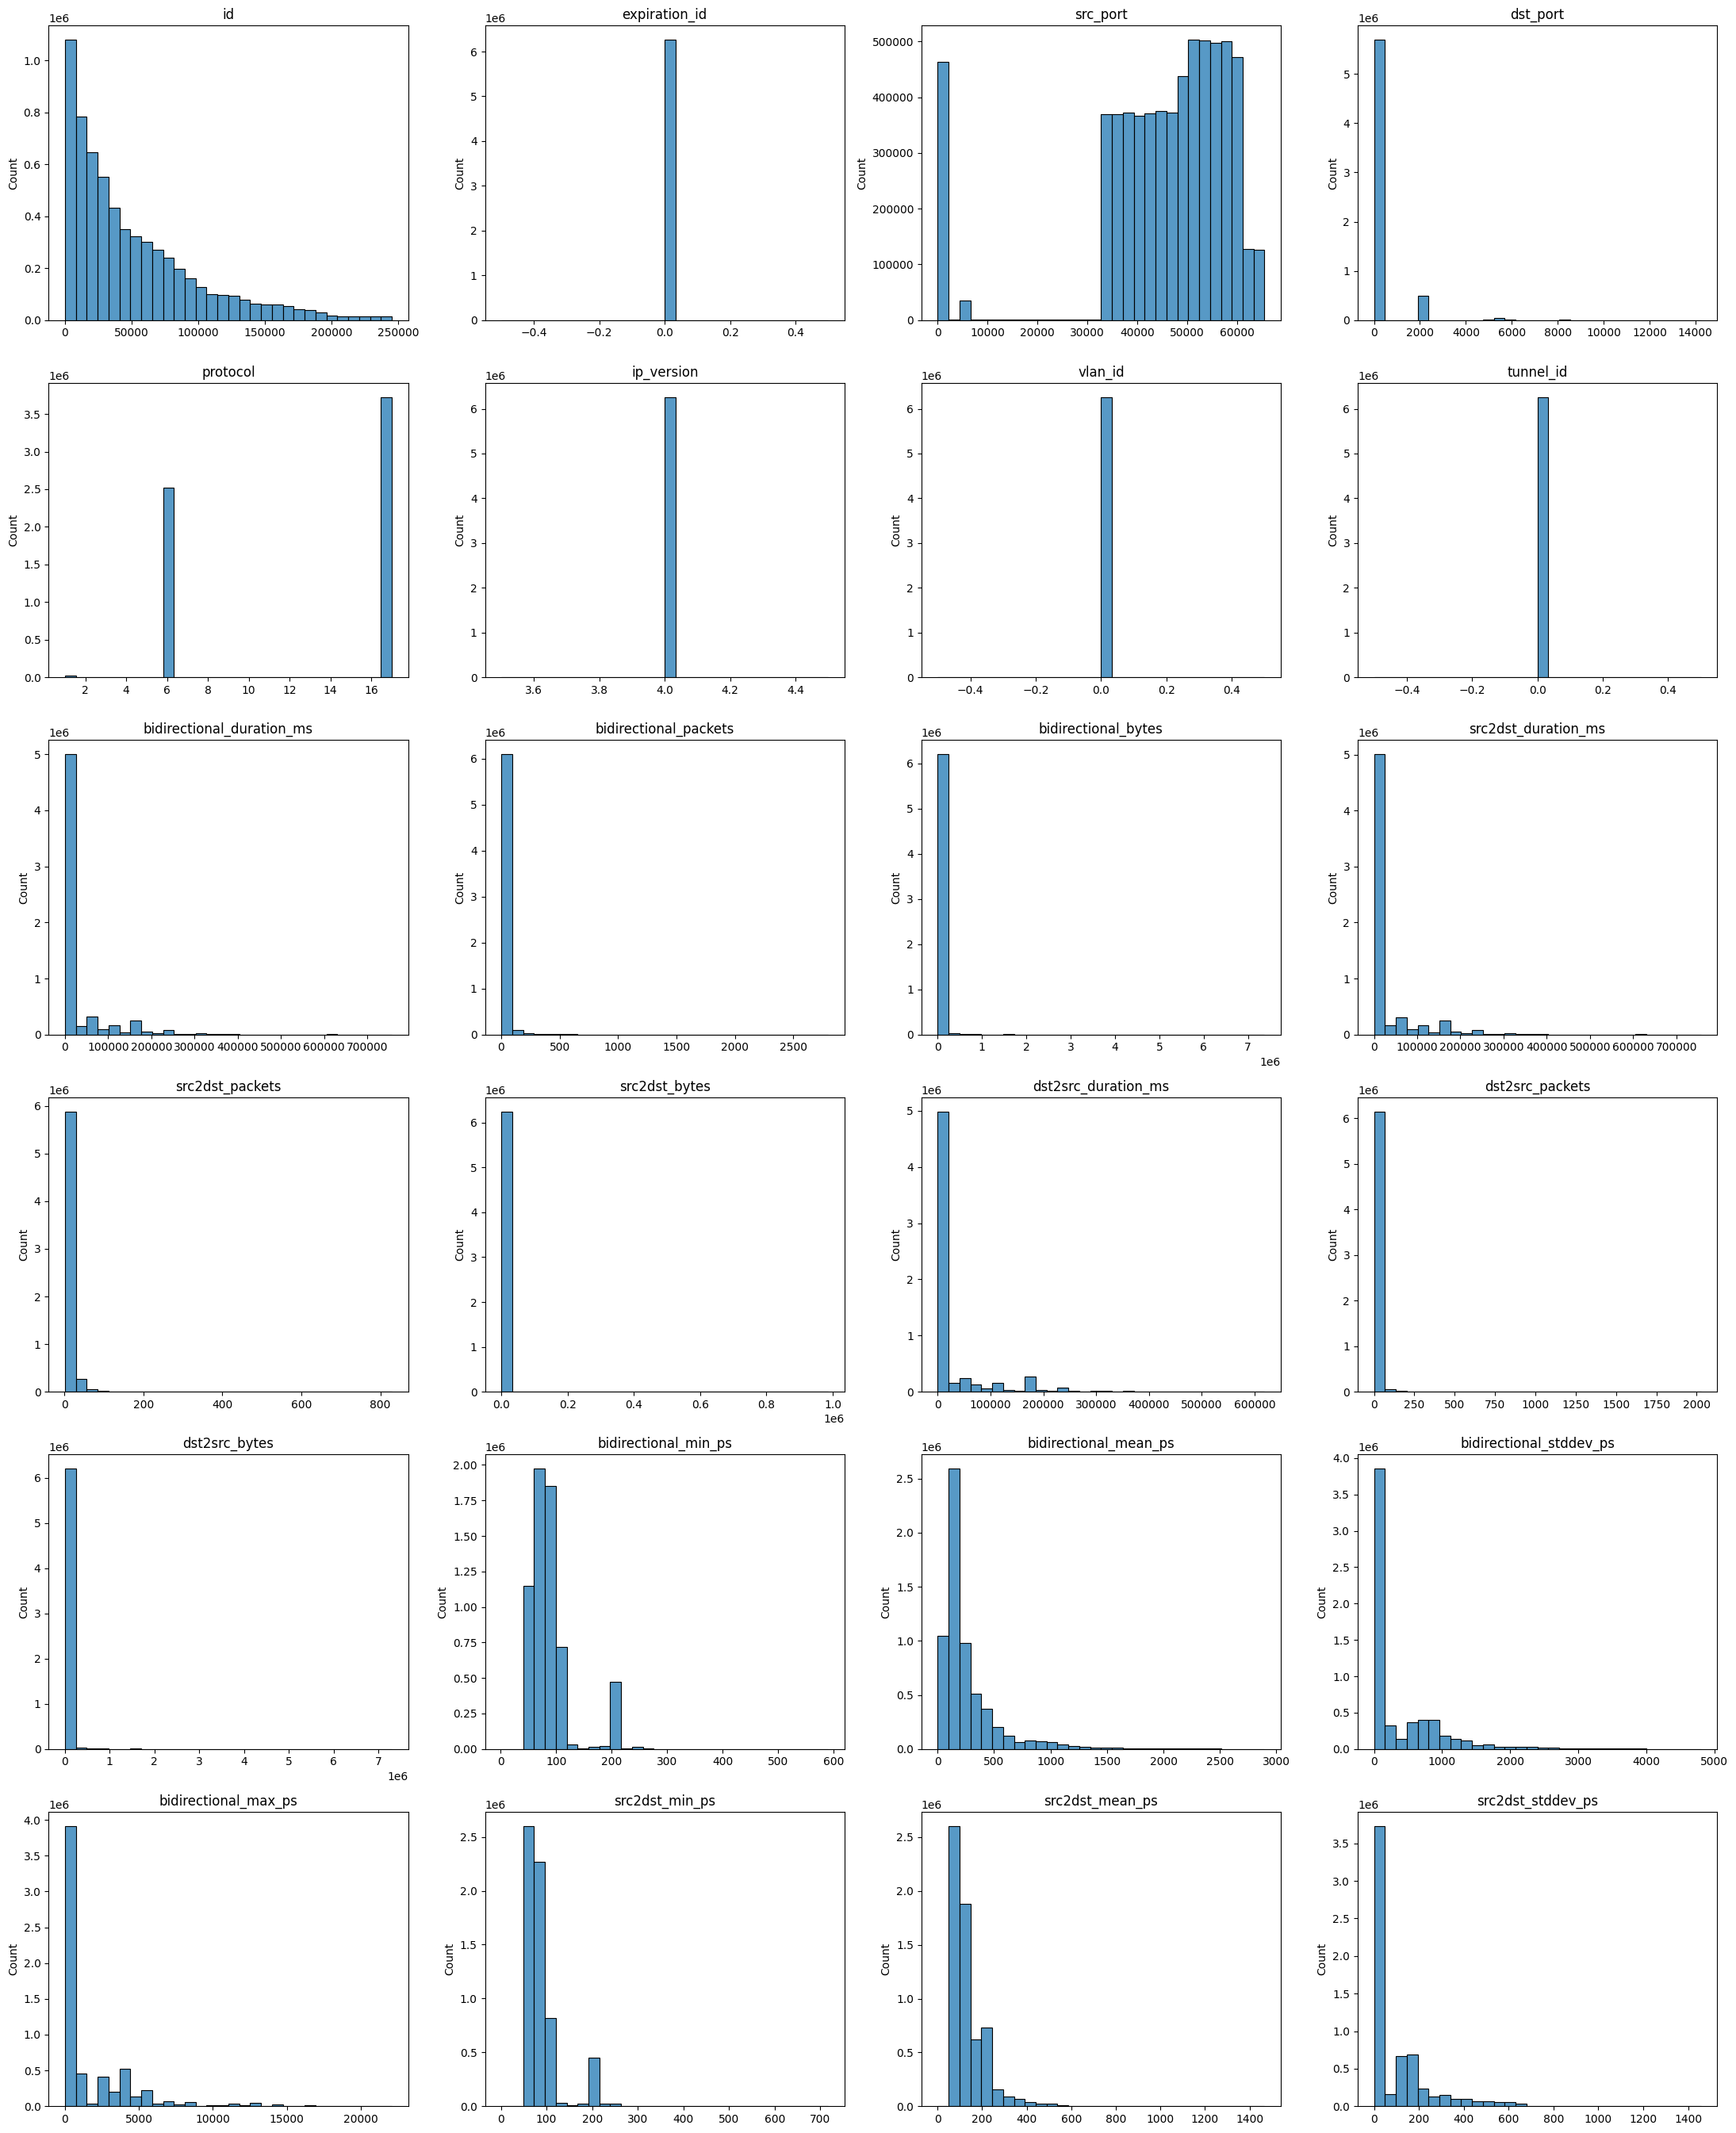

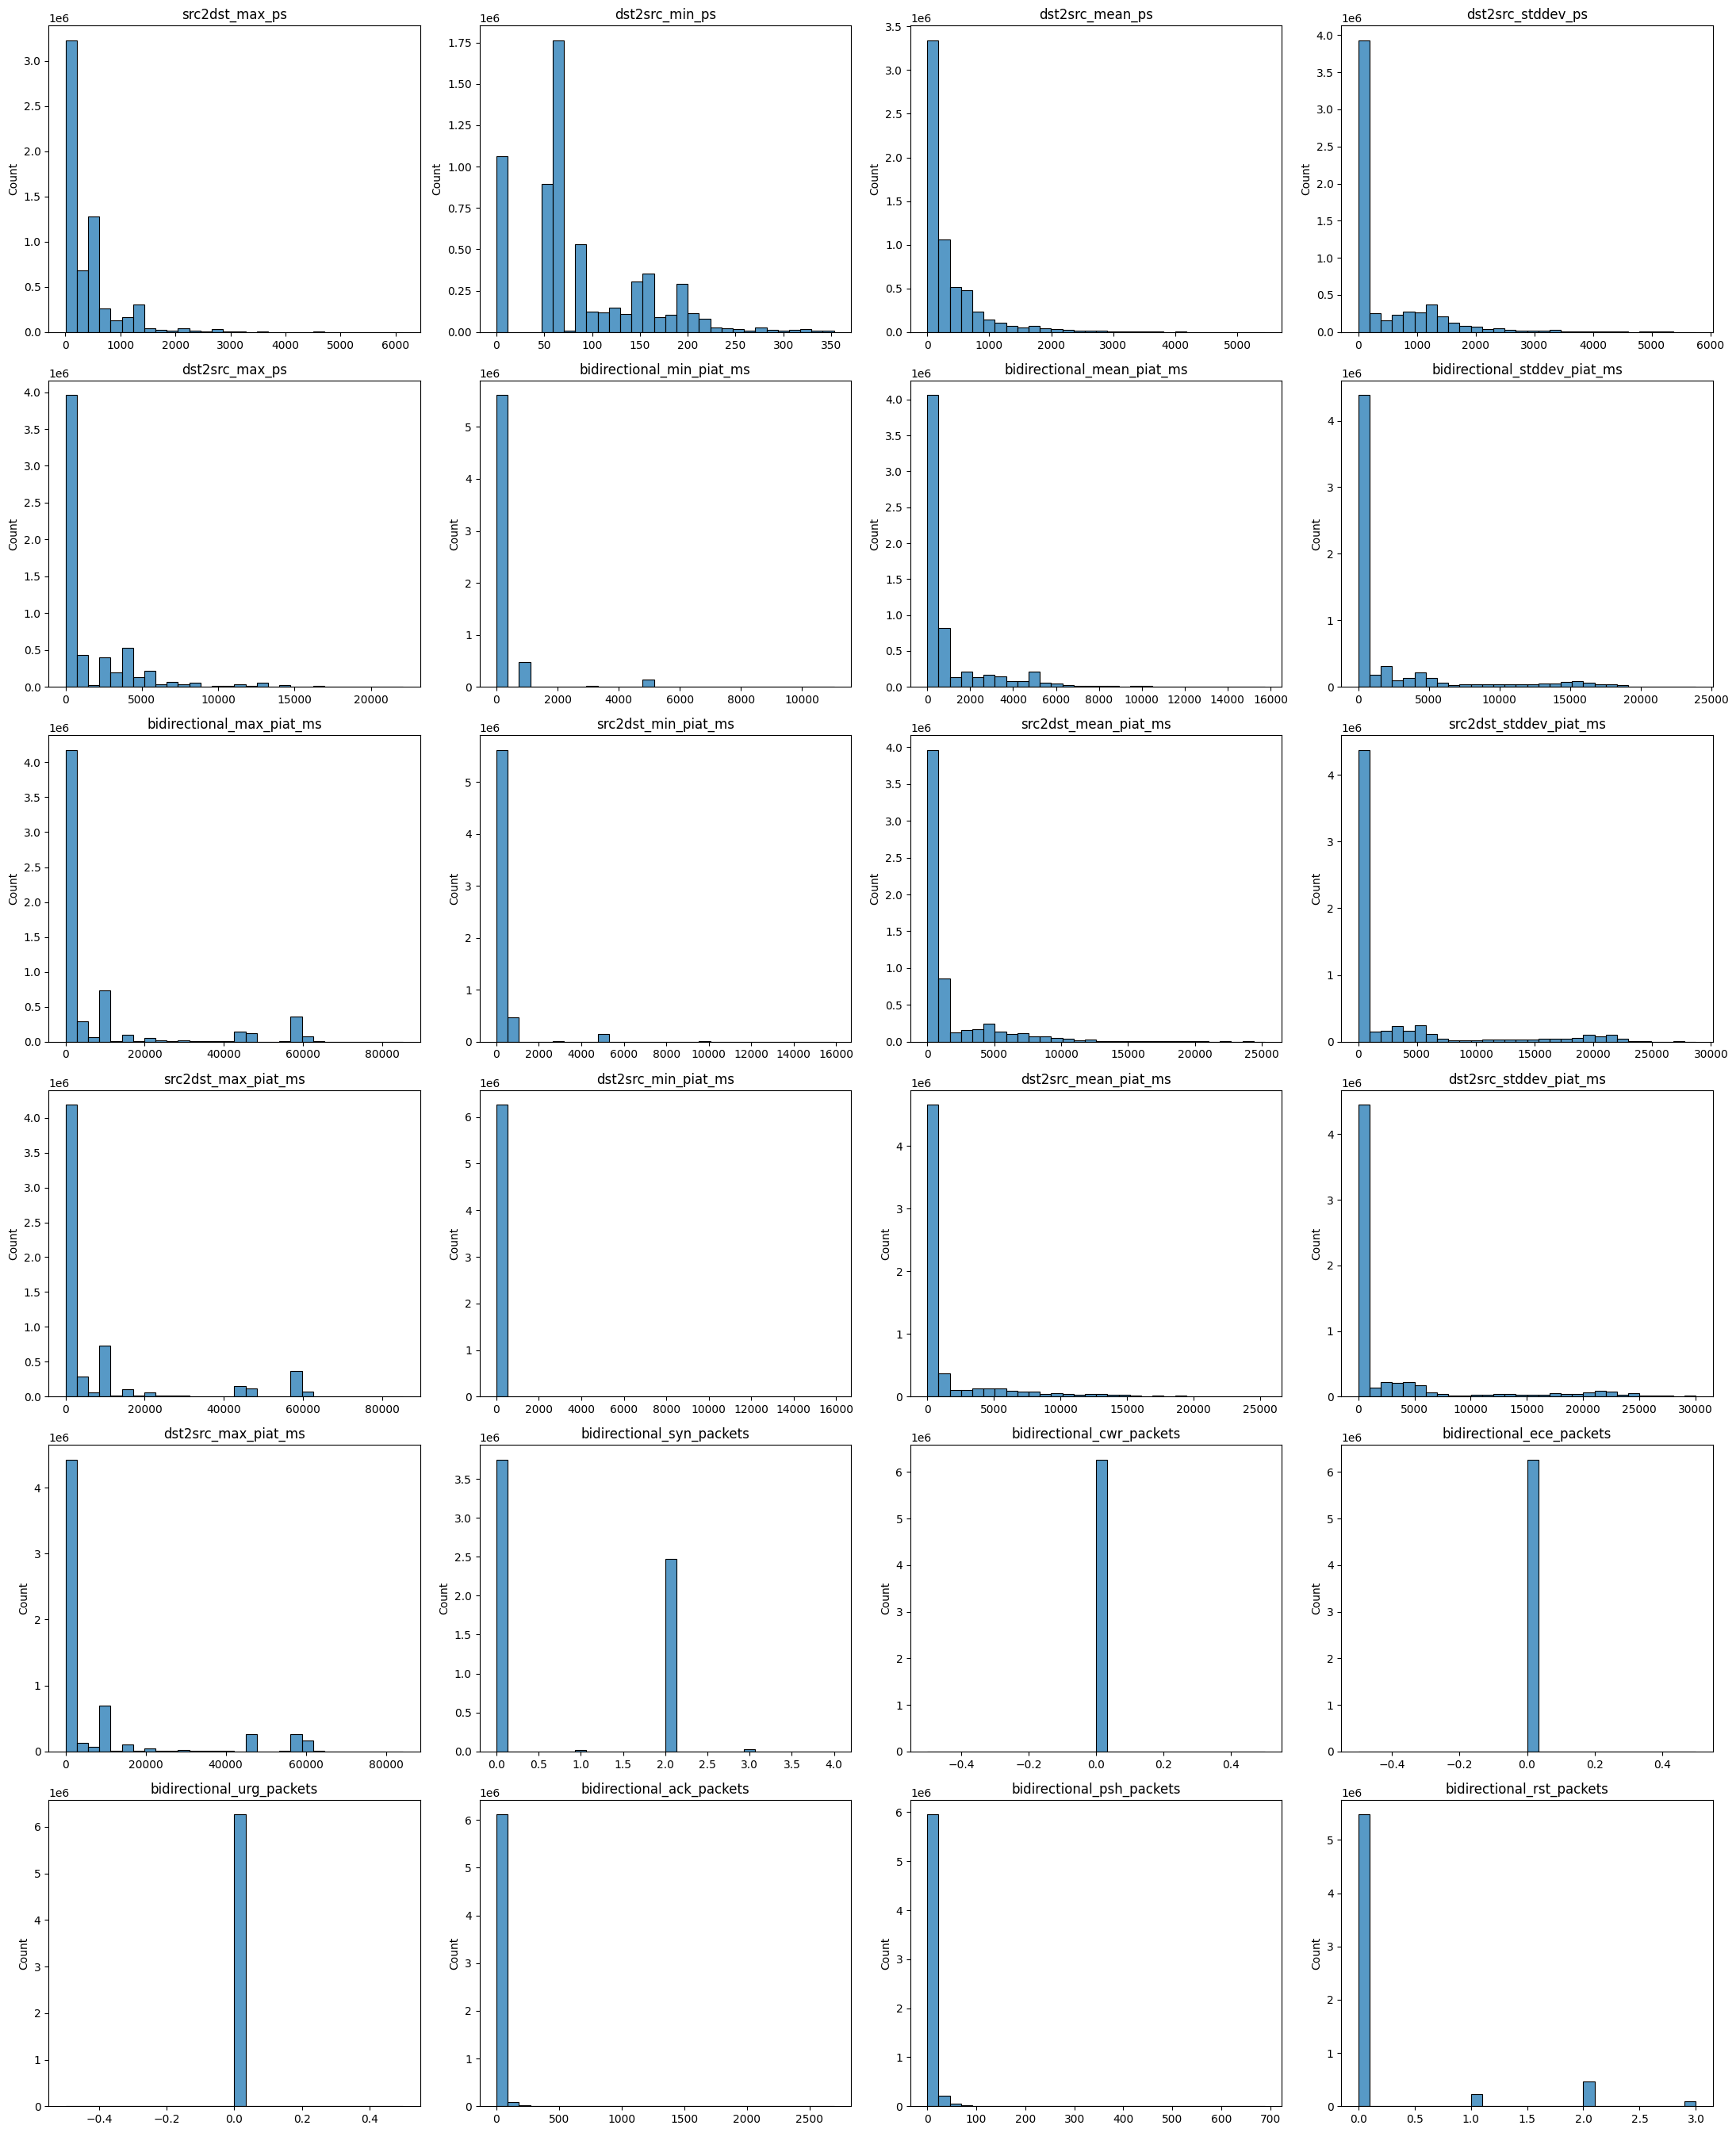

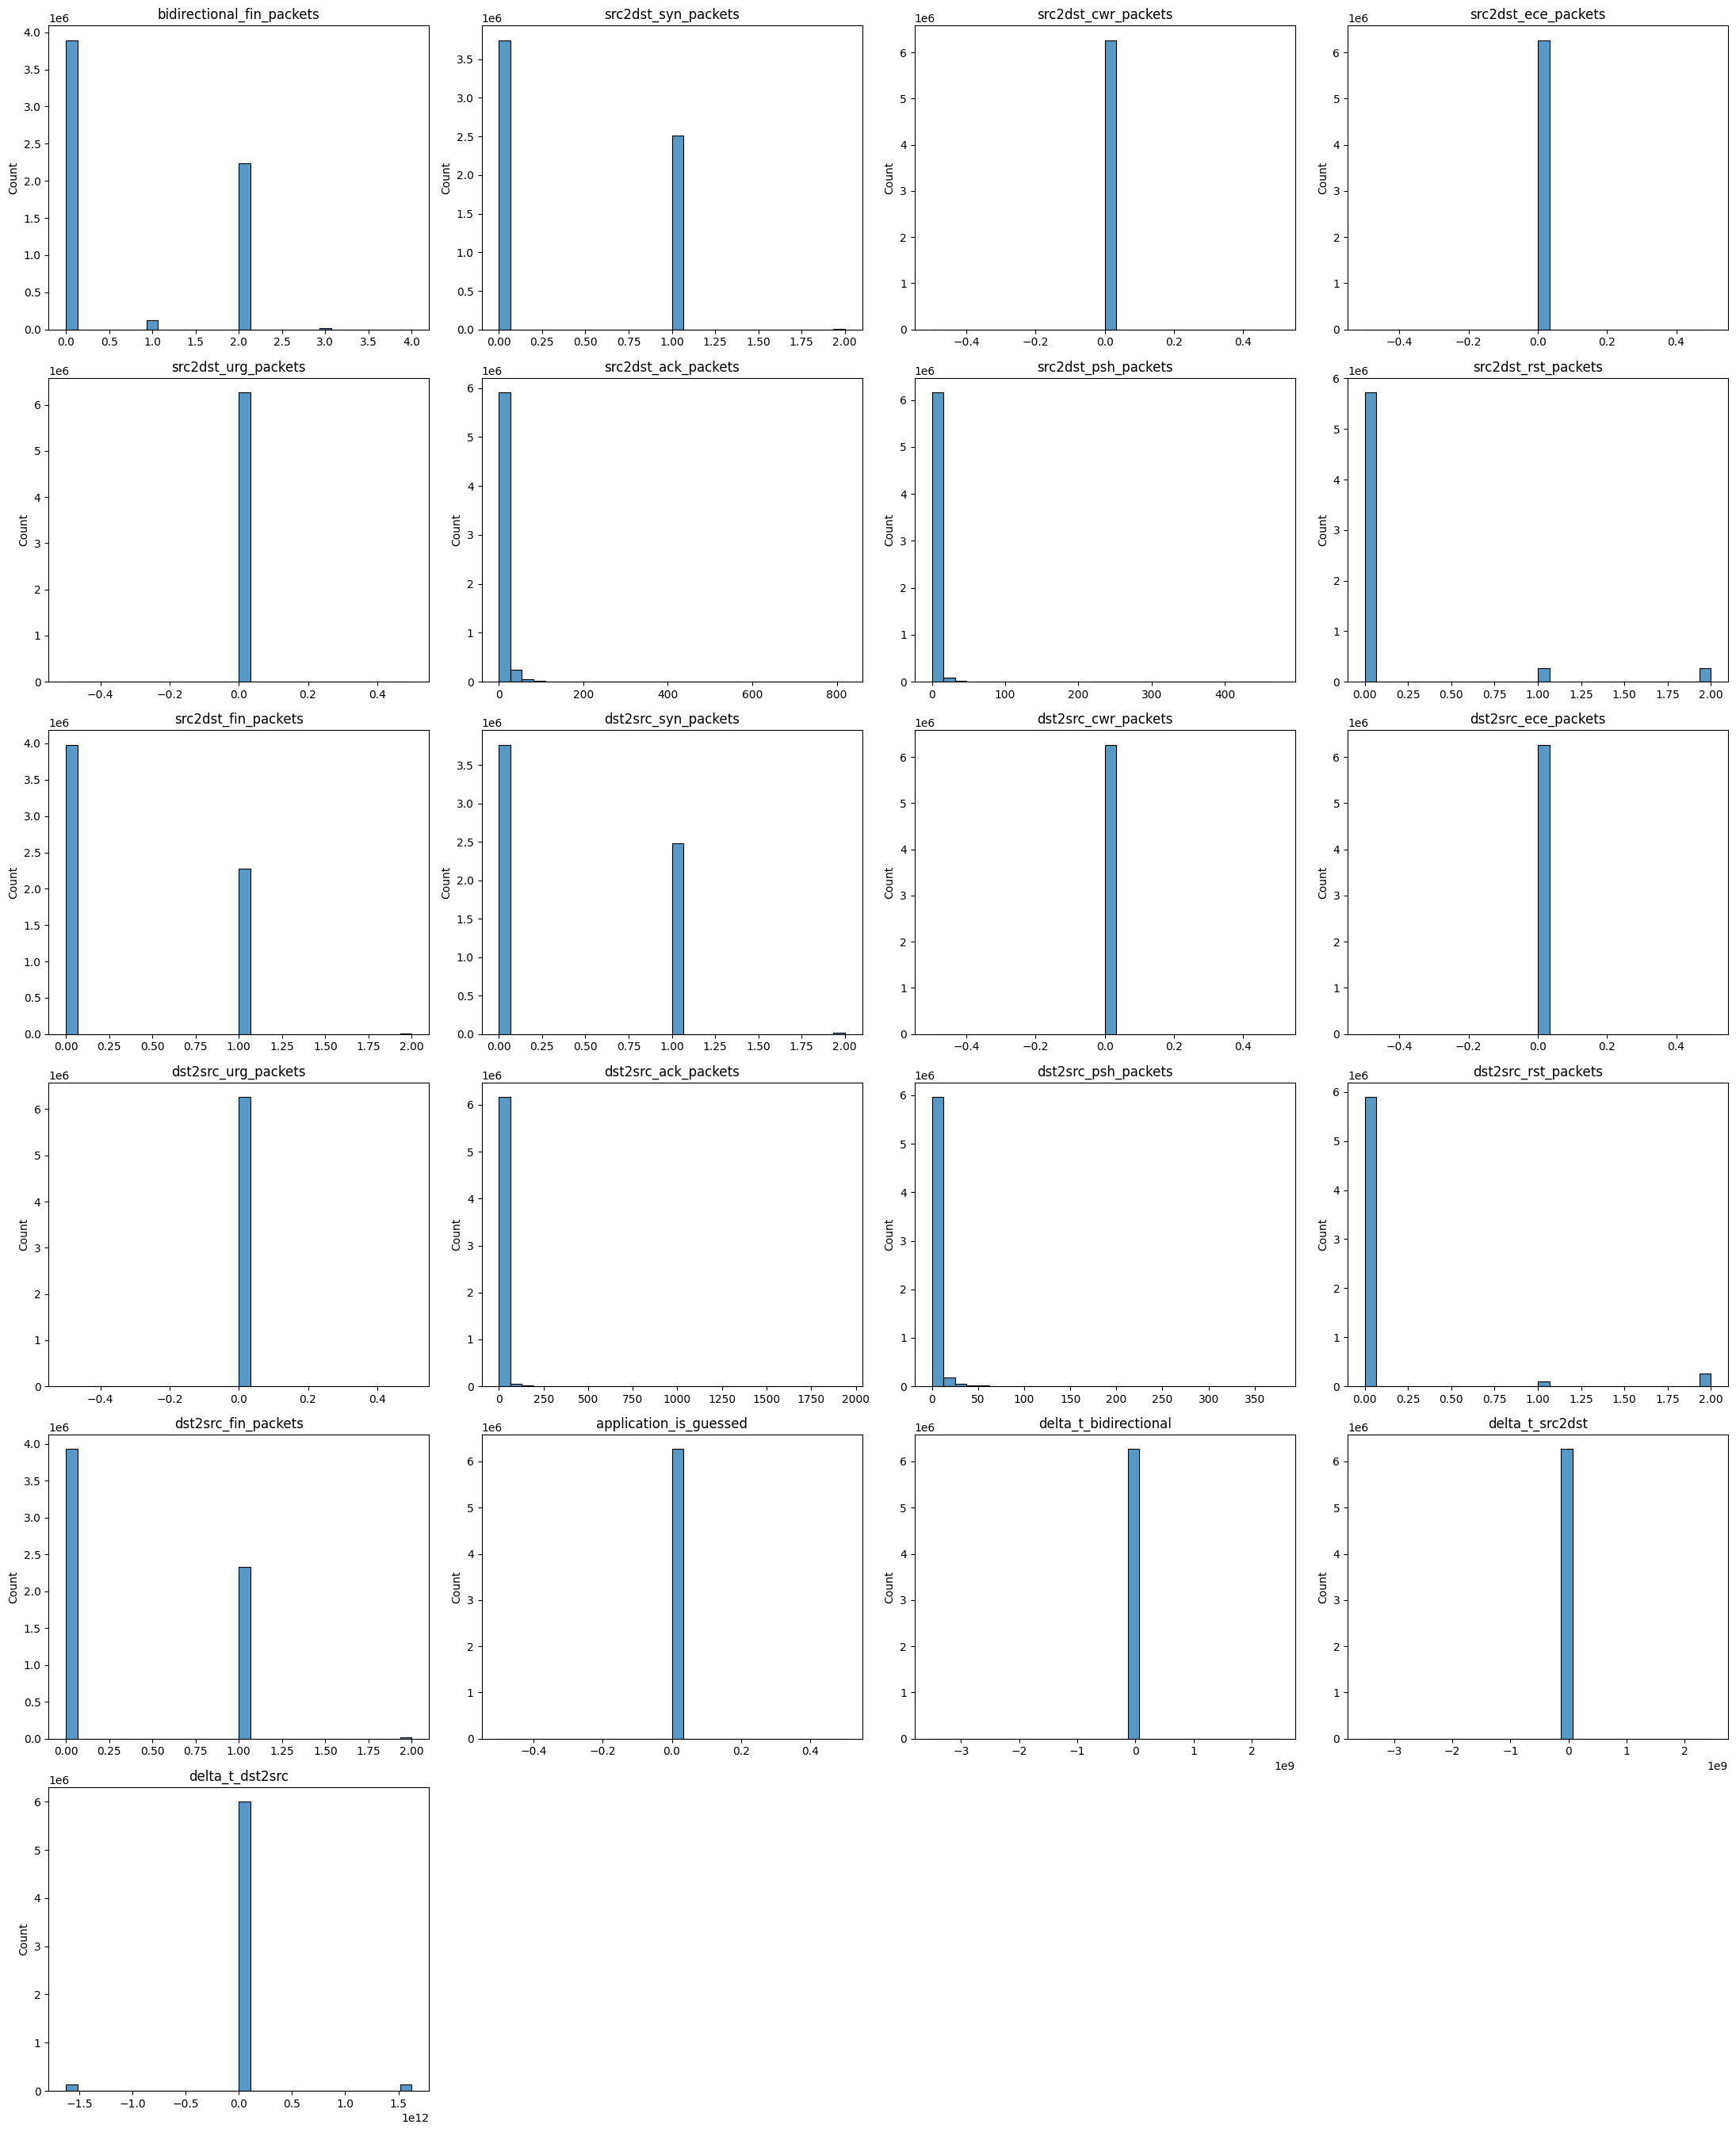

In [44]:
data = unraveled_flows if 'unraveled_flows' in globals() and not unraveled_flows.empty else unraveled_flows

num_cols = data.select_dtypes(include=np.number).columns.tolist()
n_per_fig = 24
n_cols = 4

for start in range(0, len(num_cols), n_per_fig):
    cols_chunk = num_cols[start:start + n_per_fig]
    n_rows = int(np.ceil(len(cols_chunk) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for ax, col in zip(axes, cols_chunk):
        sns.histplot(data[col].dropna(), bins=30, kde=False, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("")
    
    for ax in axes[len(cols_chunk):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2876/1889691159.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


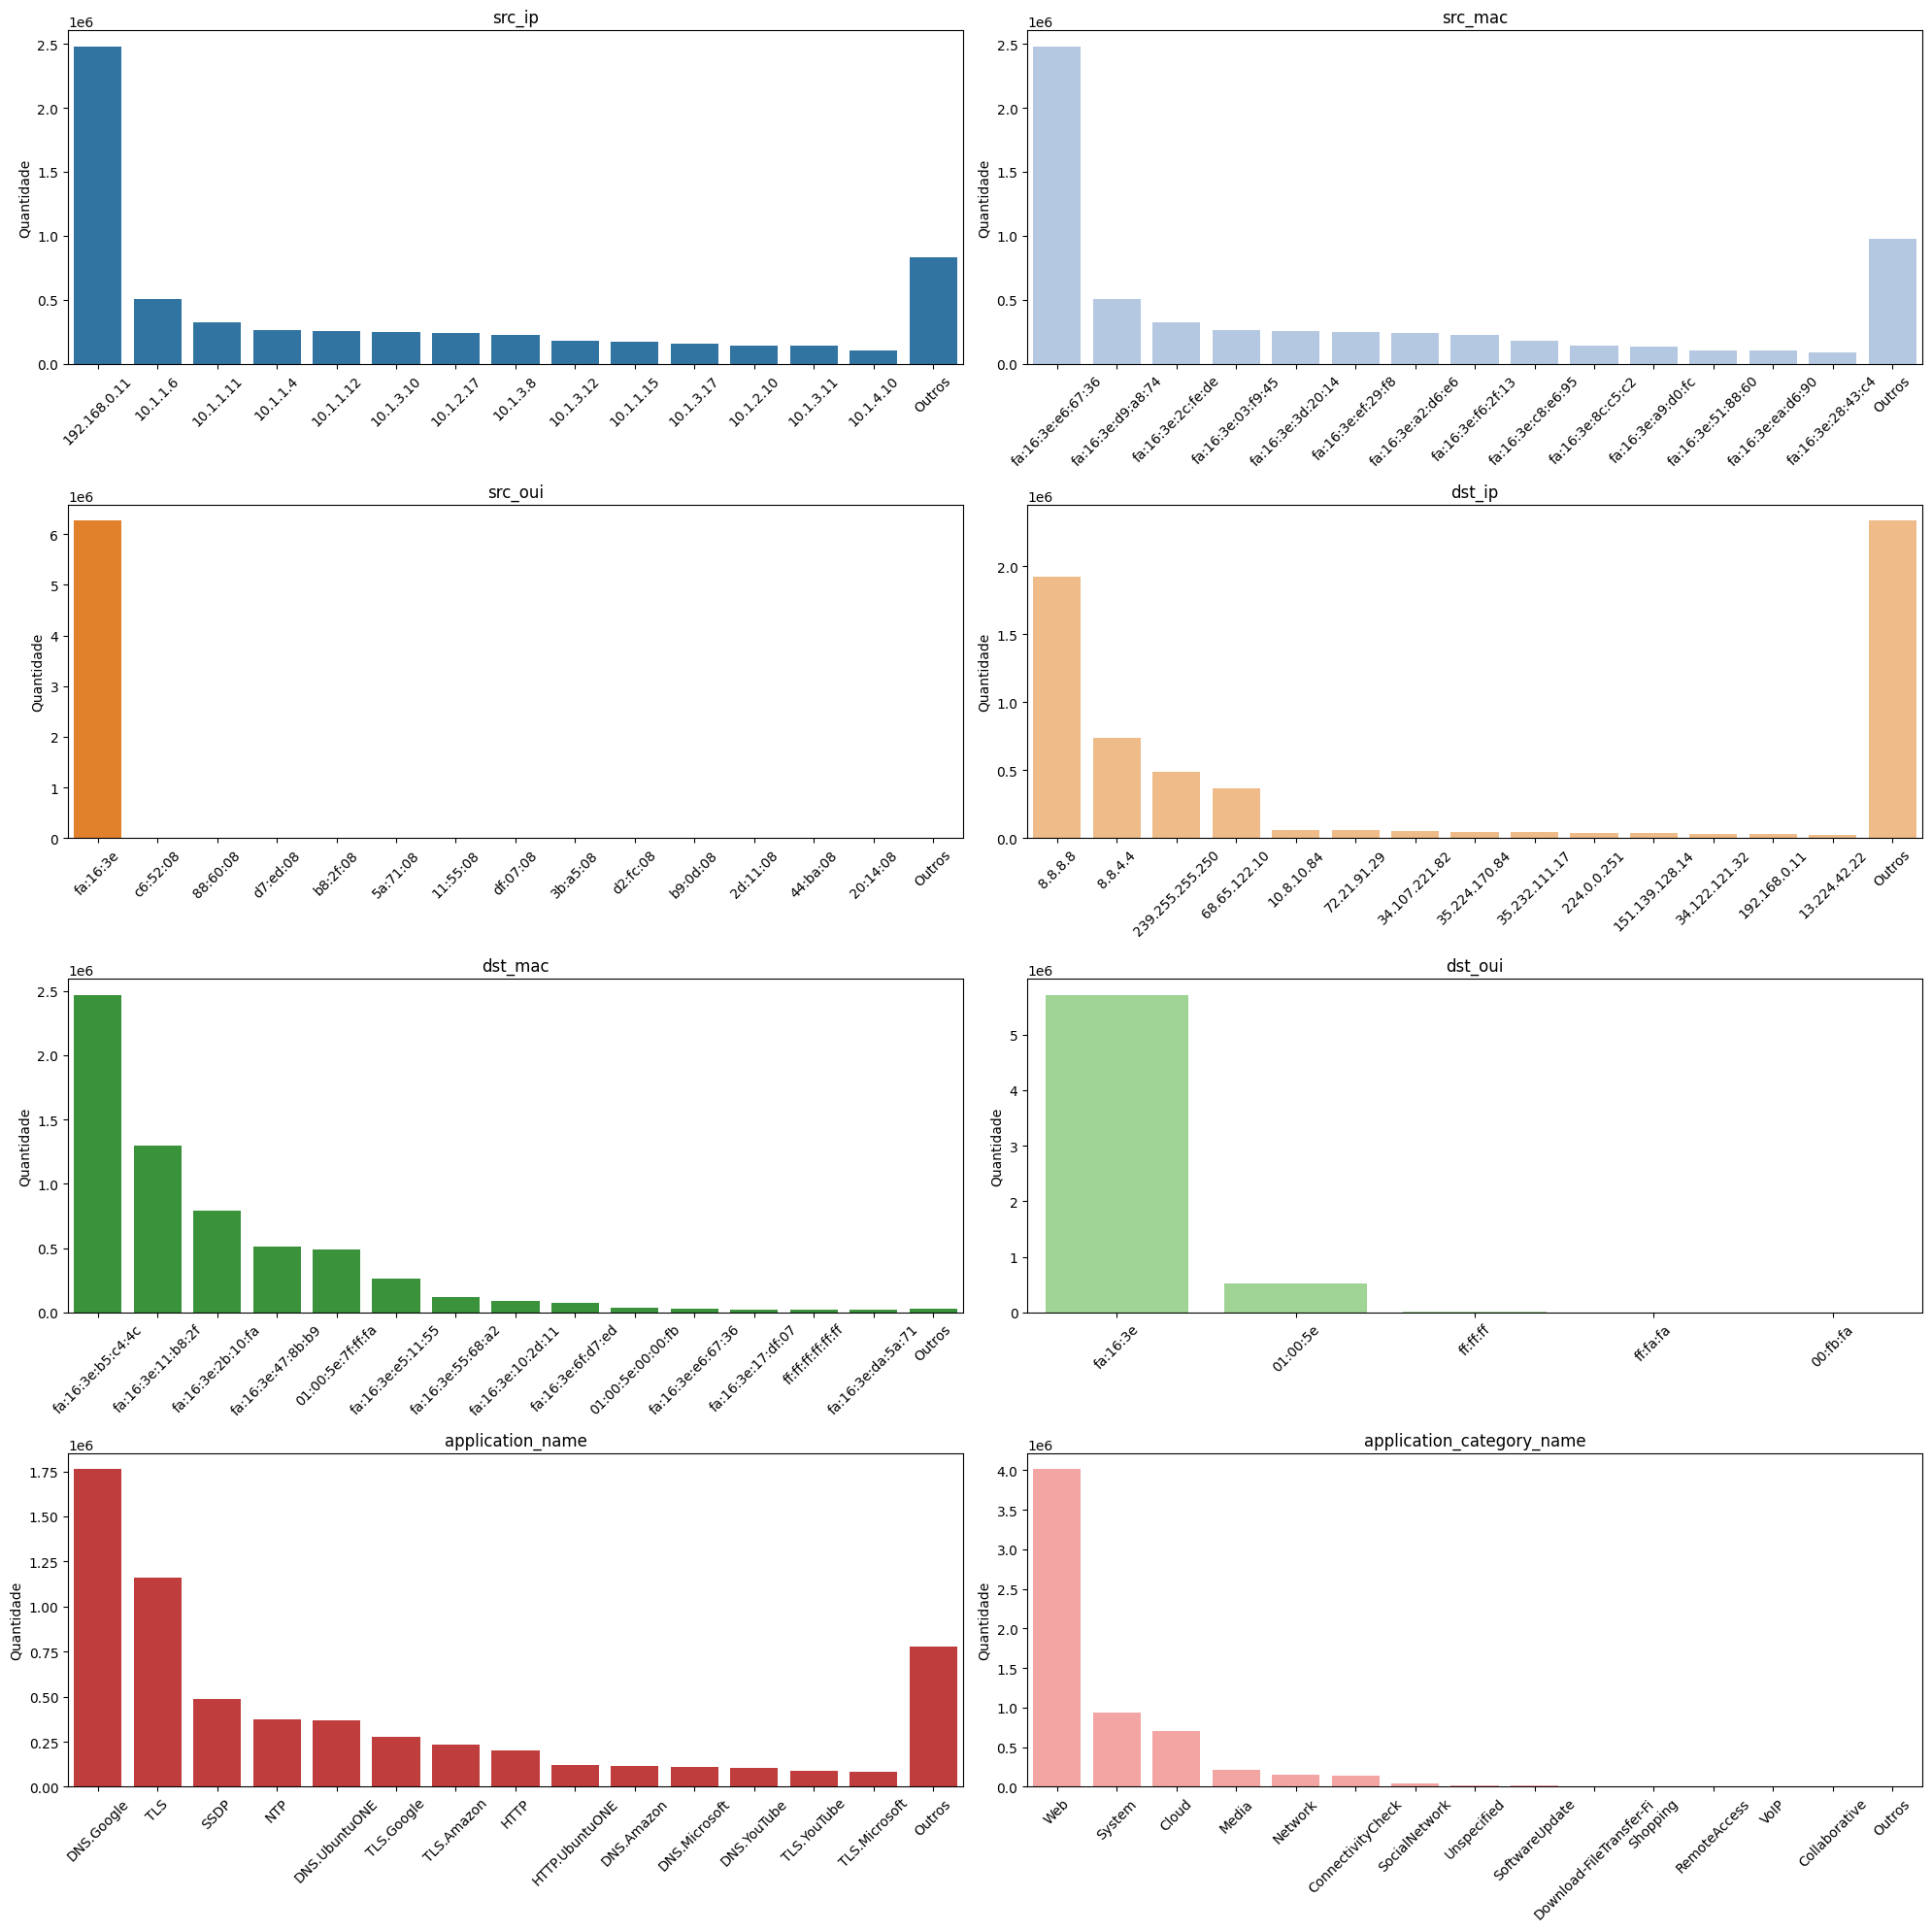

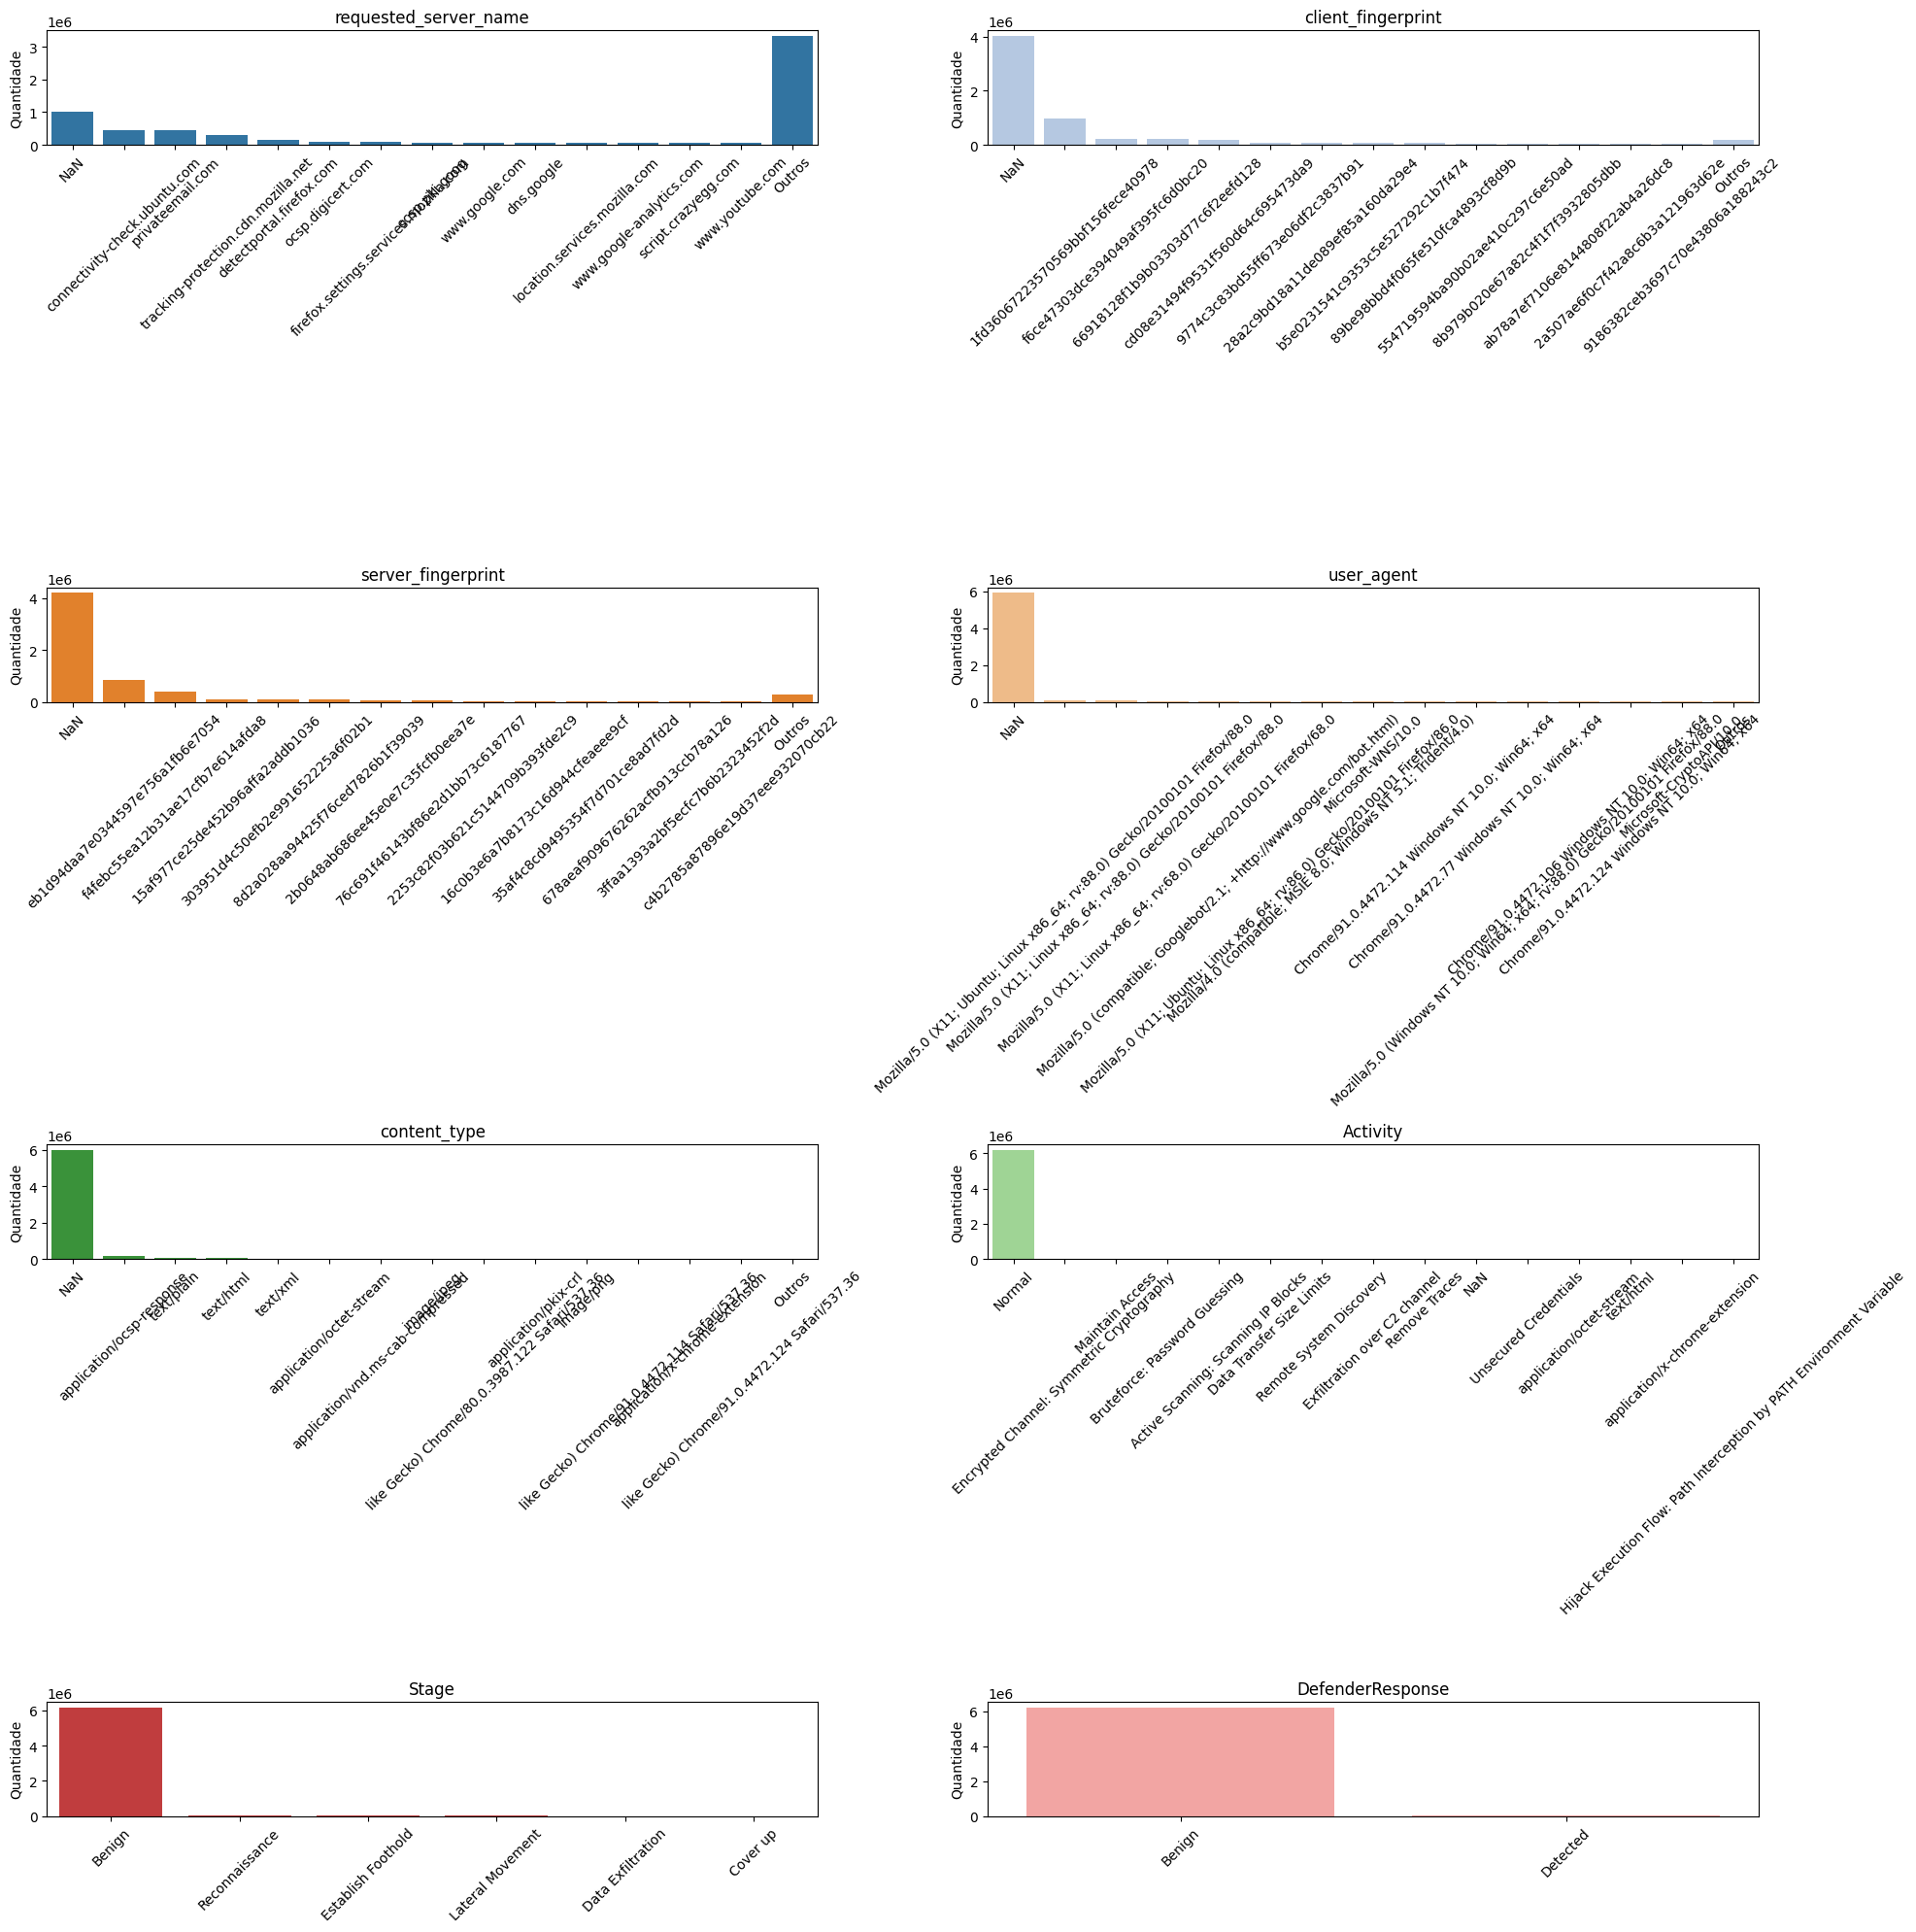

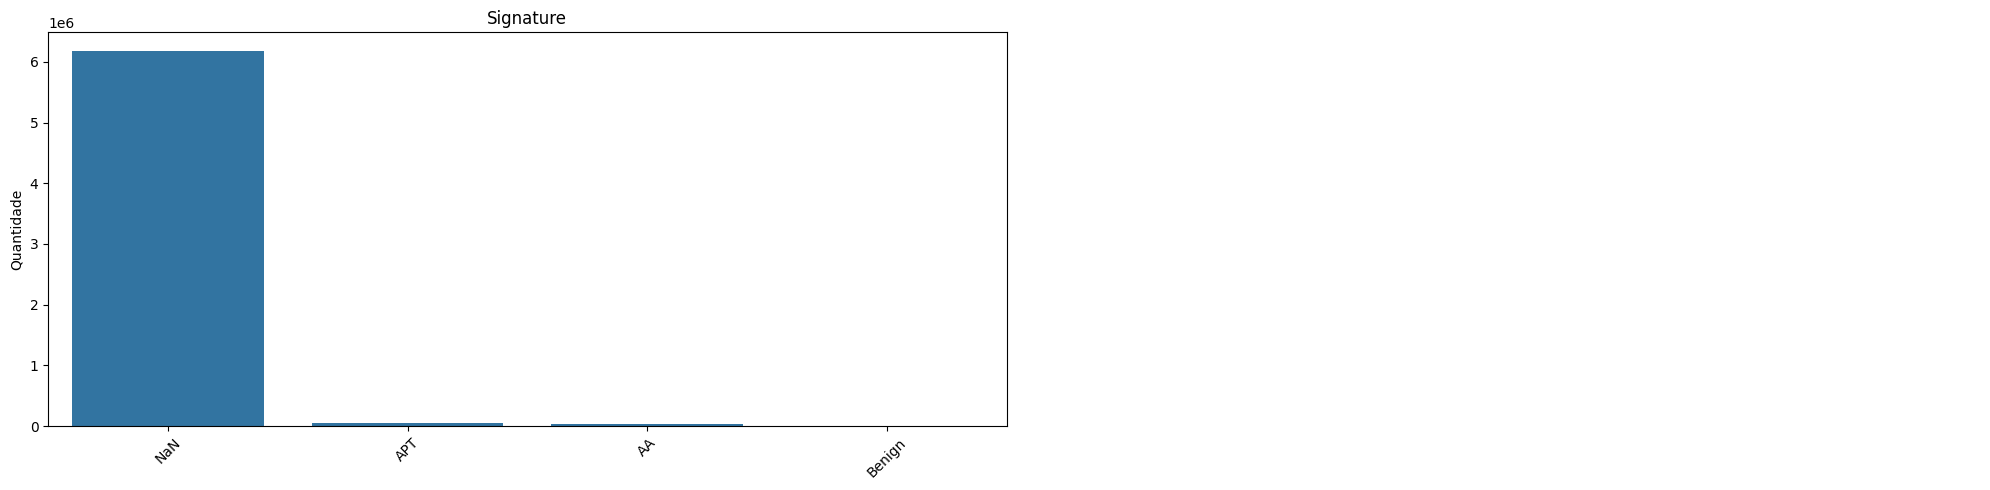

In [45]:
cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
n_per_fig = 8
n_cols = 2
max_categories = 15
palette = plt.cm.tab20.colors

for start in range(0, len(cat_cols), n_per_fig):
    cols_chunk = cat_cols[start:start + n_per_fig]
    n_rows = int(np.ceil(len(cols_chunk) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, col) in enumerate(zip(axes, cols_chunk)):
        vc = data[col].fillna("NaN").astype(str).value_counts()
        if len(vc) > max_categories:
            vc = pd.concat([vc.head(max_categories - 1), pd.Series({"Outros": vc.iloc[max_categories - 1:].sum()})])
        
        color = palette[i % len(palette)]
        sns.barplot(x=vc.index, y=vc.values, ax=ax, color=color)
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Quantidade")
        ax.tick_params(axis='x', rotation=45)
    
    for ax in axes[len(cols_chunk):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

In [46]:
print('Stage Distribution:')
for stage in unraveled_flows['Stage'].unique():
    print(f"  {stage}: {len(unraveled_flows[unraveled_flows['Stage'] == stage])}")
    
    for activity in unraveled_flows[unraveled_flows['Stage'] == stage]['Activity'].unique():
        print(f"    {activity}: {len(unraveled_flows[(unraveled_flows['Stage'] == stage) & (unraveled_flows['Activity'] == activity)])}")

Stage Distribution:
  Benign: 6176824
    Normal: 6176679
    nan: 0
    application/octet-stream: 43
    text/html: 6
    application/x-chrome-extension: 3
  Cover up: 313
    Remove Traces: 313
  Data Exfiltration: 5274
    Data Transfer Size Limits: 4787
    Unsecured Credentials: 64
    Exfiltration over C2 channel: 423
  Establish Foothold: 26377
    Encrypted Channel: Symmetric Cryptography: 26374
    Hijack Execution Flow: Path Interception by PATH Environment Variable: 3
  Lateral Movement: 26311
    Remote System Discovery: 187
    Maintain Access: 26124
  Reconnaissance: 30696
    Remote System Discovery: 357
    Active Scanning: Scanning IP Blocks: 8658
    Bruteforce: Password Guessing: 21681


In [47]:
src_ip_alvo = "10.1.1.11"
dst_ip_alvo = "10.1.5.20"
src_port_alvo = 33134
dst_port_alvo = 5044
protocol = 6
stage_alvo = "Benign" 

base_df = unraveled_flows if "unraveled_flows" in globals() and not unraveled_flows.empty else unraveled_flows

filtro = (
    (base_df["src_ip"] == src_ip_alvo) &
    (base_df["dst_ip"] == dst_ip_alvo) 
    # (base_df["src_port"] == src_port_alvo) &
    # (base_df["dst_port"] == dst_port_alvo) &
    # (base_df["protocol"] == protocol) &
    # (base_df["Stage"] == stage_alvo)
)

qtd_fluxos = filtro.sum()
print(f"Quantidade de fluxos encontrados: {qtd_fluxos}")

resultado = base_df.loc[filtro].head().transpose()

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
):
    print(resultado.to_string())

Quantidade de fluxos encontrados: 341
                                          24639              24643              24644              24650              24651
id                                           86                  1                284                184                312
expiration_id                                 0                  0                  0                  0                  0
src_ip                                10.1.1.11          10.1.1.11          10.1.1.11          10.1.1.11          10.1.1.11
src_mac                       fa:16:3e:2c:fe:de  fa:16:3e:17:df:07  fa:16:3e:2c:fe:de  fa:16:3e:17:df:07  fa:16:3e:2c:fe:de
src_oui                                fa:16:3e           fa:16:3e           fa:16:3e           fa:16:3e           fa:16:3e
src_port                                  39276              39280              39280              39284              39284
dst_ip                                10.1.5.20          10.1.5.20          10.1.5.20         

In [48]:
unraveled_flows.nunique()

id                       245004
expiration_id                 1
src_ip                      104
src_mac                      86
src_oui                      17
                          ...  
DefenderResponse              2
Signature                     3
delta_t_bidirectional    178934
delta_t_src2dst          178934
delta_t_dst2src          410951
Length: 86, dtype: int64

In [49]:
print(f"Número de linhas únicas: {len(unraveled_flows.drop_duplicates())}")

Número de linhas únicas: 6265790


In [50]:
unraveled_flows.head(20)

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,...,server_fingerprint,user_agent,content_type,Activity,Stage,DefenderResponse,Signature,delta_t_bidirectional,delta_t_src2dst,delta_t_dst2src
0,37575,0,0.0.0.0,fa:16:3e:c7:60:b5,fa:16:3e,68,255.255.255.255,ff:ff:ff:ff:ff:ff,ff:ff:ff,67,...,NaN,NaN,NaN,Normal,Benign,Benign,NaN,0.000000e+00,0.000000e+00,0.000000e+00
1,292,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,5353,224.0.0.251,01:00:5e:00:00:fb,01:00:5e,5353,...,NaN,NaN,NaN,Normal,Benign,Benign,NaN,-1.681810e+09,-1.681810e+09,0.000000e+00
2,576,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,5353,224.0.0.251,01:00:5e:00:00:fb,01:00:5e,5353,...,NaN,NaN,NaN,Normal,Benign,Benign,NaN,2.263409e+06,2.263409e+06,0.000000e+00
3,1241,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,5353,224.0.0.251,01:00:5e:00:00:fb,01:00:5e,5353,...,NaN,NaN,NaN,Normal,Benign,Benign,NaN,1.336691e+06,1.336691e+06,0.000000e+00
4,2718,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,38522,10.1.1.15,fa:16:3e:26:54:23,fa:16:3e,5986,...,17e97216fa7f4ec8c43090c6eed97c25,NaN,NaN,Normal,Benign,Benign,NaN,1.680438e+06,1.680438e+06,1.622058e+12
5,2508,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,38526,10.1.1.15,fa:16:3e:26:54:23,fa:16:3e,5986,...,17e97216fa7f4ec8c43090c6eed97c25,NaN,NaN,Normal,Benign,Benign,NaN,1.264100e+04,1.264100e+04,1.263900e+04
6,4082,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,38592,10.1.1.15,fa:16:3e:26:54:23,fa:16:3e,5986,...,17e97216fa7f4ec8c43090c6eed97c25,NaN,NaN,Normal,Benign,Benign,NaN,4.447070e+05,4.447070e+05,4.447080e+05
7,2994,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,38596,10.1.1.15,fa:16:3e:26:54:23,fa:16:3e,5986,...,17e97216fa7f4ec8c43090c6eed97c25,NaN,NaN,Normal,Benign,Benign,NaN,1.268100e+04,1.268100e+04,1.268100e+04
8,4335,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,5353,224.0.0.251,01:00:5e:00:00:fb,01:00:5e,5353,...,NaN,NaN,NaN,Normal,Benign,Benign,NaN,1.129420e+05,1.129420e+05,-1.622058e+12
9,7411,0,10.1.1.10,fa:16:3e:e5:11:55,fa:16:3e,38740,10.1.1.15,fa:16:3e:26:54:23,fa:16:3e,5986,...,17e97216fa7f4ec8c43090c6eed97c25,NaN,NaN,Normal,Benign,Benign,NaN,1.079303e+06,1.079303e+06,1.622059e+12
